In [28]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, BatchNormalization
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

In [2]:
# tree-based models
x_train = pd.read_csv('../data/processed/x_train.csv')
x_cv = pd.read_csv('../data/processed/x_cv.csv')
x_test = pd.read_csv('../data/processed/x_test.csv')

y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_cv = pd.read_csv('../data/processed/y_cv.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# logistic regression and neural networks
x_train_scaled = pd.read_csv('../data/processed/x_train_scaled.csv')
x_cv_scaled = pd.read_csv('../data/processed/x_cv_scaled.csv')
x_test_scaled = pd.read_csv('../data/processed/x_test_scaled.csv')

cs_test = pd.read_csv('../data/processed/cs_test_processed.csv')
cs_test_scaled = pd.read_csv('../data/processed/cs_test_scaled.csv')

# for GridSearchCV and RandomizedSearchCV use x_train + x_cv
x_train_full = np.concatenate((x_train, x_cv), axis=0)
x_train_sc_full = np.concatenate((x_train_scaled, x_cv_scaled), axis=0)
y_train_full = np.concatenate((y_train, y_cv), axis=0)

In [3]:
scores = []

In [4]:
def build_search_cv(param_grid, model, x_train, y_train):
    if isinstance(model, (XGBClassifier, RandomForestClassifier)):
        grid = RandomizedSearchCV(model, param_grid, scoring=['roc_auc', 'f1'], refit='roc_auc', n_jobs=6, random_state=42)
    else:
        grid = GridSearchCV(model, param_grid, scoring=['roc_auc', 'f1'], refit='roc_auc')

    grid.fit(x_train, y_train)
    
    best_idx = grid.best_index_
    best_f1 = grid.cv_results_['mean_test_f1'][best_idx]

    print(grid.best_params_, grid.best_score_, 'F1:', best_f1)

    best_model = grid.best_estimator_
    scores.append({'model_name': type(model).__name__, 'roc_auc': grid.best_score_, 'f1': best_f1})

    return best_model

In [5]:
lr_params = {'solver': ['liblinear', 'lbfgs', 'sag']}
lr_model = build_search_cv(lr_params, LogisticRegression(max_iter=1000, random_state=42), x_train_sc_full, y_train_full)

{'solver': 'sag'} 0.8390259041558087 F1: 0.22010378809542389


In [6]:
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 7, 10, 15]}
dt_model = build_search_cv(dt_params, DecisionTreeClassifier(random_state=42), x_train_full, y_train_full)

{'max_depth': 5, 'min_samples_split': 2} 0.8473715608775569 F1: 0.2635706024906309


In [7]:
rf_params = {'n_estimators': [100, 200, 400], 'max_depth': [5, 10, 12, 20], 'min_samples_split':[2, 5, 10, 15]}
rf_model = build_search_cv(rf_params, RandomForestClassifier(random_state=42, n_jobs=1), x_train_full, y_train_full)

{'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10} 0.8642045025083075 F1: 0.25939791425850994


In [8]:
xgbc_params = {'n_estimators': [100, 200, 400, 700], 'learning_rate': [0.01, 0.03, 0.05], 'max_depth': [5, 10, 12, 20]}
xgbc_model = build_search_cv(xgbc_params, XGBClassifier(random_state=42, n_jobs=1), x_train_full, y_train_full)

{'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.03} 0.865175895788991 F1: 0.2959923587655757


In [9]:
def build_models():
    model_1 = Sequential([
        Dense(units=25, activation='relu'),
        Dense(units=15, activation='relu'),
        Dense(units=1, activation='linear'),
    ], name='model_1')

    model_2 = Sequential([
        Dense(units=30, activation='relu'),
        Dense(units=12, activation='relu'),
        Dense(units=7, activation='relu'),
        Dense(units=1, activation='linear'),
    ], name='model_2')

    model_3 = Sequential([
        Dense(units=32, activation='relu'),
        BatchNormalization(),
        Dense(units=16, activation='relu'),
        BatchNormalization(),
        Dense(units=8, activation='relu'),
        BatchNormalization(),
        Dense(units=12, activation='relu'),
        BatchNormalization(),
        Dense(units=1, activation='linear'),
    ], name='model_3')

    models = [model_1, model_2, model_3]
    return models

In [10]:
models_nn = build_models()

early_stop = EarlyStopping(
    monitor='val_AUC',      
    patience=20,            
    restore_best_weights=True,  
    mode='max'               
)

histories = {}

for model in models_nn:
    model.compile(
        loss=BinaryCrossentropy(from_logits=True),
        optimizer=Adam(learning_rate=0.01),
        metrics=['AUC'] 
    )

    history = model.fit(
        x_train_scaled, y_train,      
        validation_data=(x_cv_scaled, y_cv),
        epochs=200,             
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )

    histories[model.name] = history
    
    logits_cv = model.predict(x_cv_scaled, verbose=0).flatten()
    y_pred_proba_cv = tf.sigmoid(logits_cv).numpy()
    y_pred_class_cv = (y_pred_proba_cv >= 0.5).astype(int)

    cv_auc = roc_auc_score(y_cv, y_pred_proba_cv)
    cv_f1 = f1_score(y_cv, y_pred_class_cv)

    model.save(f'../models/{model.name}.keras')

    print(f'{model.name}: ROC-AUC={cv_auc:.4f}, F1={cv_f1:.4f}')
    scores.append({'model_name': model.name, 'model': model, 'roc_auc': cv_auc, 'f1': cv_f1})  

model_1: ROC-AUC=0.8572, F1=0.3338
model_2: ROC-AUC=0.8579, F1=0.3445
model_3: ROC-AUC=0.8440, F1=0.3782


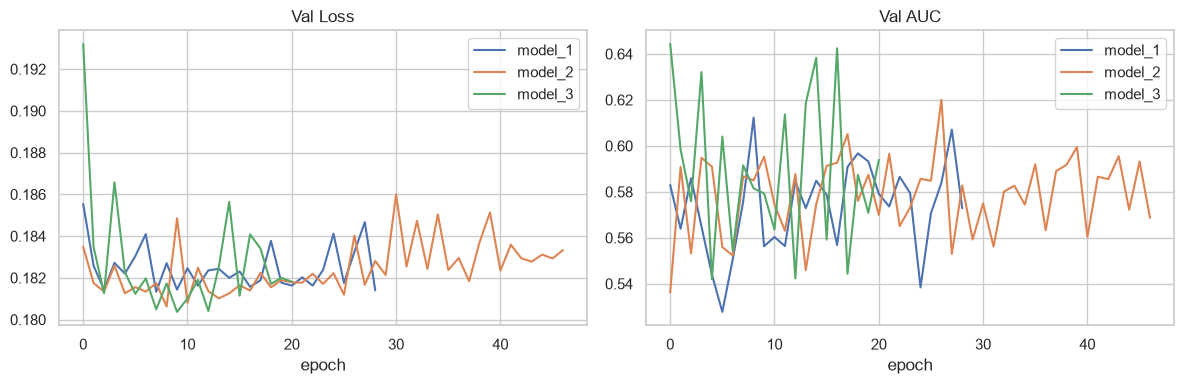

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, history in histories.items():
    axes[0].plot(history.history['val_loss'], label=name)
    axes[1].plot(history.history['val_AUC'], label=name)  

axes[0].set_title('Val Loss')
axes[0].set_xlabel('epoch')
axes[1].set_title('Val AUC')
axes[1].set_xlabel('epoch')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

In [11]:
results_df = pd.DataFrame(scores).sort_values('roc_auc', ascending=False)
results_df

,model_name,roc_auc,f1,model
3,XGBClassifier,0.865176,0.295992,NaN
2,RandomForestClassifier,0.864205,0.259398,NaN
5,model_2,0.857915,0.344529,"<Sequential name=model_2, built=True>"
4,model_1,0.857241,0.333793,"<Sequential name=model_1, built=True>"
1,DecisionTreeClassifier,0.847372,0.263571,NaN
6,model_3,0.844041,0.378199,"<Sequential name=model_3, built=True>"
0,LogisticRegression,0.839026,0.220104,NaN


In [22]:
bias_variance_results = []

classical_models_bv = {
    'LogisticRegression': (lr_model, x_train_sc_full),
    'DecisionTreeClassifier': (dt_model, x_train_full),
    'RandomForestClassifier': (rf_model, x_train_full),
    'XGBClassifier': (xgbc_model, x_train_full),
}

for name, (model, x_data) in classical_models_bv.items():
    train_proba = model.predict_proba(x_data)[:, 1]
    train_auc = roc_auc_score(y_train_full, train_proba)

    cv_auc = results_df.loc[results_df['model_name'] == name, 'roc_auc'].values[0]

    gap = train_auc - cv_auc
    bias_variance_results.append({
        'model_name': name,
        'train_auc': train_auc,
        'cv_auc': cv_auc,
        'gap': gap
    })

    print(f'{name}: train={train_auc:.4f}, cv={cv_auc:.4f}, gap={gap:.4f}')

bias_variance_df = pd.DataFrame(bias_variance_results).sort_values('gap', ascending=False)
bias_variance_df

LogisticRegression: train=0.8396, cv=0.8390, gap=0.0005
DecisionTreeClassifier: train=0.8504, cv=0.8474, gap=0.0030
RandomForestClassifier: train=0.8934, cv=0.8642, gap=0.0292
XGBClassifier: train=0.8913, cv=0.8652, gap=0.0262


,model_name,train_auc,cv_auc,gap
2,RandomForestClassifier,0.893425,0.864205,0.029220
3,XGBClassifier,0.891346,0.865176,0.026170
1,DecisionTreeClassifier,0.850418,0.847372,0.003046
0,LogisticRegression,0.839558,0.839026,0.000532


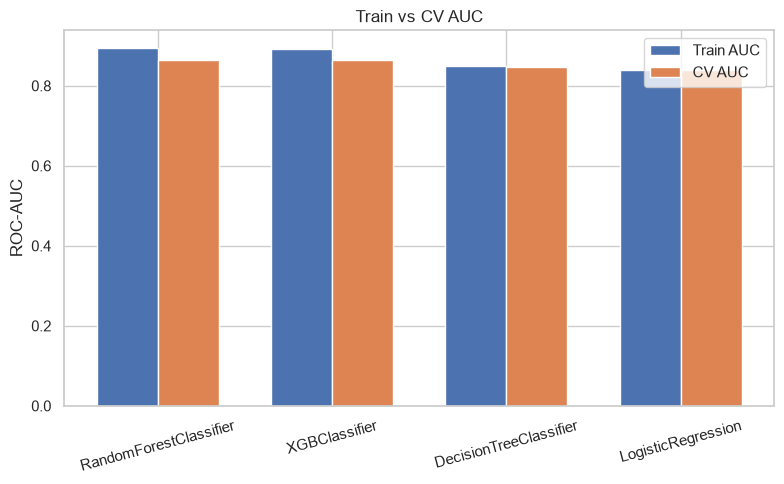

In [24]:
plt.figure(figsize=(8, 5))
x_pos = range(len(bias_variance_df))

plt.bar(x_pos, bias_variance_df['train_auc'], width=0.35, label='Train AUC', align='edge')
plt.bar([p + 0.35 for p in x_pos], bias_variance_df['cv_auc'], width=0.35, label='CV AUC', align='edge')

plt.xticks([p + 0.35 for p in x_pos], bias_variance_df['model_name'], rotation=15)
plt.ylabel('ROC-AUC')
plt.title('Train vs CV AUC')
plt.legend()
plt.tight_layout()
plt.show()

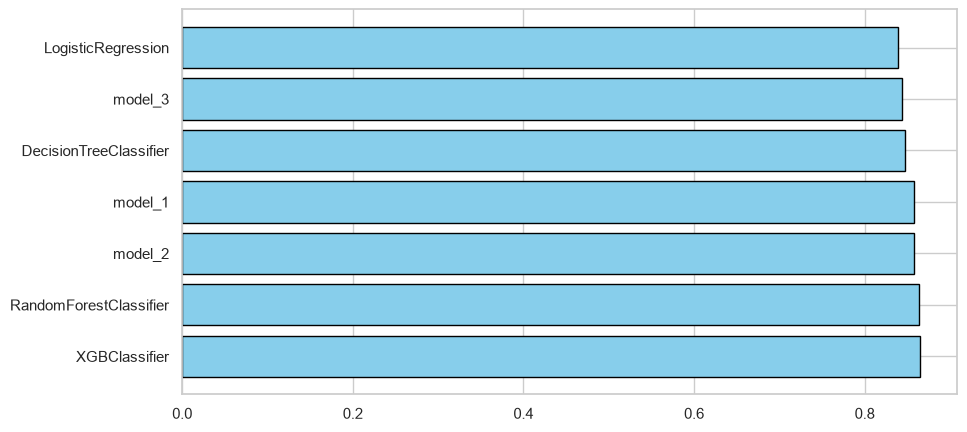

In [12]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    results_df["model_name"], results_df["roc_auc"], color="skyblue", edgecolor="black"
)

In [13]:
y_predict_proba_cv = xgbc_model.predict_proba(x_cv)[:, 1]

for t in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    y_pred_t = (y_predict_proba_cv >= t).astype(int)
    print(f'threshold={t}: recall={recall_score(y_cv, y_pred_t):.3f}, precision={precision_score(y_cv, y_pred_t):.3f}, f1={f1_score(y_cv, y_pred_t):.3f}')

threshold=0.15: recall=0.637, precision=0.367, f1=0.466
threshold=0.2: recall=0.571, precision=0.434, f1=0.493
threshold=0.25: recall=0.508, precision=0.480, f1=0.494
threshold=0.3: recall=0.449, precision=0.522, f1=0.483
threshold=0.35: recall=0.394, precision=0.575, f1=0.468
threshold=0.4: recall=0.332, precision=0.612, f1=0.431


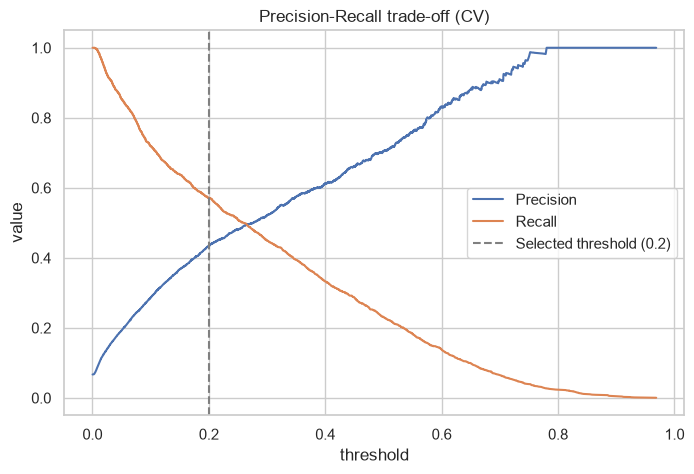

In [29]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_cv, y_predict_proba_cv)

plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, precisions[:-1], label='Precision')
plt.plot(pr_thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.2, color='gray', linestyle='--', label='Selected threshold (0.2)')
plt.xlabel('threshold')
plt.ylabel('value')
plt.title('Precision-Recall trade-off (CV)')
plt.legend()
plt.show()

In [14]:
y_predict_proba_test = xgbc_model.predict_proba(x_test)[:, 1]
y_predict_class_test = (y_predict_proba_test >= 0.2).astype(int)

test_auc = roc_auc_score(y_test, y_predict_proba_test)
test_f1 = f1_score(y_test, y_predict_class_test)

print(f'Test ROC-AUC: {test_auc:.4f}')
print(f'Test F1: {test_f1:.4f}')

Test ROC-AUC: 0.8618
Test F1: 0.4344


In [31]:
print(classification_report(y_test, y_predict_class_test))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27877
           1       0.38      0.51      0.43      2002

    accuracy                           0.91     29879
   macro avg       0.67      0.73      0.69     29879
weighted avg       0.92      0.91      0.92     29879



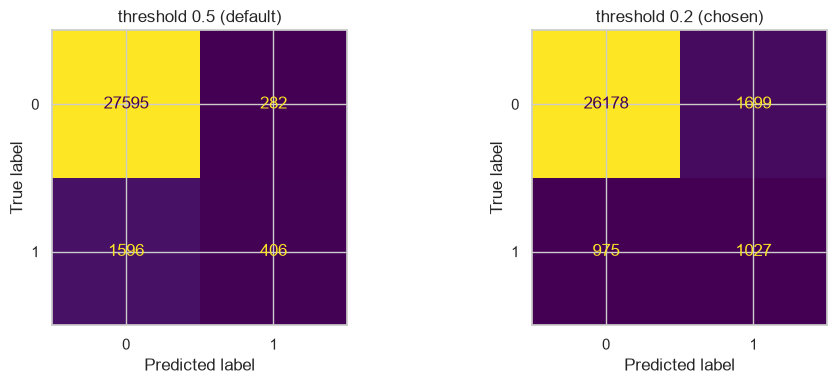

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_pred_default = (y_predict_proba_test >= 0.5).astype(int)
y_pred_chosen = (y_predict_proba_test >= 0.2).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)
cm_chosen = confusion_matrix(y_test, y_pred_chosen)

ConfusionMatrixDisplay(cm_default).plot(ax=axes[0], colorbar=False)
axes[0].set_title('threshold 0.5 (default)')

ConfusionMatrixDisplay(cm_chosen).plot(ax=axes[1], colorbar=False)
axes[1].set_title('threshold 0.2 (chosen)')

plt.tight_layout()
plt.show()

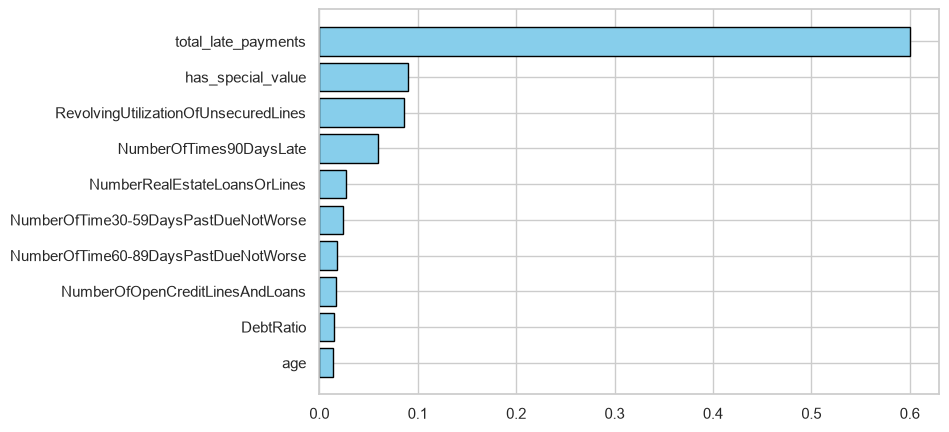

In [16]:
xgbc_features = xgbc_model.feature_importances_
feature_names = x_train.columns

importance_df = pd.DataFrame({"Feature": feature_names, "Importance": xgbc_features})
importance_df = importance_df.sort_values(by="Importance", ascending=True).tail(10)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    importance_df["Feature"], importance_df["Importance"], color="skyblue", edgecolor="black"
)

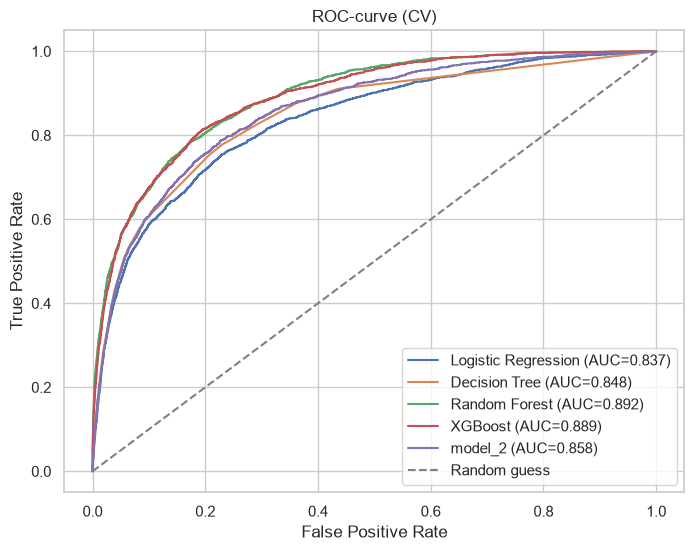

In [19]:
plt.figure(figsize=(8, 6))

classical_models = {
    'Logistic Regression': (lr_model, x_cv_scaled), 
    'Decision Tree': (dt_model, x_cv),
    'Random Forest': (rf_model, x_cv),
    'XGBoost': (xgbc_model, x_cv),
}

for name, (model, x_cv_data) in classical_models.items():
    proba = model.predict_proba(x_cv_data.values)[:, 1]
    fpr, tpr, _ = roc_curve(y_cv, proba)
    auc = roc_auc_score(y_cv, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

best_nn = models_nn[1]  
logits_cv = best_nn.predict(x_cv_scaled, verbose=0).flatten()
proba_nn = tf.sigmoid(logits_cv).numpy()
fpr_nn, tpr_nn, _ = roc_curve(y_cv, proba_nn)
auc_nn = roc_auc_score(y_cv, proba_nn)
plt.plot(fpr_nn, tpr_nn, label=f'{best_nn.name} (AUC={auc_nn:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve (CV)')
plt.legend()
plt.show()

In [20]:
joblib.dump(lr_model, '../models/logistic_regression.joblib')
joblib.dump(dt_model, '../models/decision_tree.joblib')
joblib.dump(rf_model, '../models/random_forest.joblib')
joblib.dump(xgbc_model, '../models/xgboost.joblib')

results_df.drop(columns=['model'], errors='ignore').to_csv('../models/model_comparison.csv', index=False)
results_df.to_csv('../models/model_comparison.csv', index=False)

cv_roc_auc = results_df.loc[results_df['model_name'] == 'XGBClassifier', 'roc_auc'].values[0]
final_results = {
    'model': 'XGBoost',
    'threshold': 0.2,
    'cv_roc_auc': float(cv_roc_auc),  
    'test_roc_auc': float(test_auc),
    'test_f1': float(test_f1),
}
with open('../models/final_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

In [25]:
proba_submission = xgbc_model.predict_proba(cs_test)[:, 1]

In [26]:
original_test = pd.read_csv('../data/cs-test.csv')
test_ids = original_test['Unnamed: 0']

submission = pd.DataFrame({
    'Id': test_ids,
    'Probability': proba_submission
})

submission.to_csv('../data/submission.csv', index=False)
submission.head()

,Id,Probability
0,1,0.066025
1,2,0.045657
2,3,0.011158
3,4,0.087889
4,5,0.094836


In [27]:
print(submission.shape)  
print(cs_test.shape) 
print(submission['Id'].is_unique)  
print(submission['Probability'].between(0, 1).all())   

(101503, 2)
(101503, 18)
True
True
